In [1]:
import numpy as np
import pandas as pd
import logging
from dataclasses import dataclass
# tqdm fallback if not installed
try:
    from tqdm import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import invgamma
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)
import warnings

# suppress only that specific warning
import warnings

warnings.simplefilter("ignore")



# Optional for auto ARIMA: catch binary incompatibility errors
try:
    import pmdarima as pm
    AUTO_ARIMA = True
except (ImportError, ValueError):
    AUTO_ARIMA = False

In [2]:
# ─────── CONFIG DATACLASS ───────
@dataclass
class SARIMAXConfig:
    p: int = 2
    d: int = 1
    q: int = 2
    P: int = 1
    D: int = 1
    Q: int = 1
    S: int = 5  # season length (e.g., 5 for business week)
    test_size: float = 0.1
    n_iter: int = 3000
    burn_in: int = 1000
    alpha0: float = 0.01
    beta0: float = 0.01
    random_seed: int = 42
    data_path: str = 'datasets/AAPL_xlstm_date.csv'

In [3]:
# ─────── METRIC FUNCTIONS ───────
def compute_metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

# ─────── TRAIN/TEST SPLIT ───────
def time_series_train_test_split(y, test_size):
    split = int(len(y) * (1 - test_size))
    print(len(y))
    print(split)
    return y.iloc[:split], y.iloc[split:]

In [4]:
def main(config: SARIMAXConfig):
    # 0. Logging & seed
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s %(levelname)s %(message)s'
    )
    log = logging.getLogger(__name__)
    np.random.seed(config.random_seed)

    # 1. Load data
    df = pd.read_csv(
        config.data_path,
        header=0,
        names=['Date','Open','High','Low','Close','Volume']
    )
    print(df.columns)
    print(df.dtypes)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    logged_cols = []
    for col in df.columns:
        if col not in ["Volume", "MACD", "Sentiment"]:
            logged_cols.append(col)
            df[col] = np.log(df[col])

    # Target + exogenous
    y = df['Close']
    X = df[['Open','High','Low','Volume']]

    # 2. Auto‐ARIMA for orders (optional)
    if AUTO_ARIMA:
        log.info('Running auto_arima to select orders...')
        arima_res = pm.auto_arima(
            y,
            seasonal=True,
            m=config.S,
            suppress_warnings=True,
            stepwise=True
        )
        config.p, config.d, config.q = arima_res.order
        config.P, config.D, config.Q = arima_res.seasonal_order[:-1]
        log.info(
            f"Auto ARIMA order={arima_res.order} "
            f"seasonal_order={arima_res.seasonal_order}"
        )

    # 3. Train/test split
    y_train, y_test = time_series_train_test_split(
        y, config.test_size
    )
    X_train = X.loc[y_train.index]
    X_test = X.loc[y_test.index]
    horizon = len(y_test)

    # 4. MLE SARIMAX
    log.info('Fitting MLE SARIMAX with exog...')
    mle_model = sm.tsa.SARIMAX(
        y_train,
        exog=X_train,
        order=(config.p, config.d, config.q),
        seasonal_order=(config.P, config.D, config.Q, config.S),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res_mle = mle_model.fit(disp=False)

    # Forecast with MLE
    pred_mle = res_mle.get_forecast(
        steps=horizon,
        exog=X_test
    ).predicted_mean
    y_test = np.exp(y_test)
    pred_mle = np.exp(pred_mle)
    metrics_mle = compute_metrics(y_test, pred_mle)
    log.info(f"MLE SARIMAX metrics: {metrics_mle}")

    # 5. Residual diagnostics
    lb_test = sm.stats.acorr_ljungbox(
        res_mle.resid, lags=[10], return_df=True
    )
    log.info(
        f"Ljung-Box (lag=10) p-value: "
        f"{lb_test['lb_pvalue'].iloc[0]:.4f}"
    )

    # 6. Bayesian sampling of sigma²
    T = len(y_train)
    resid = y_train - res_mle.fittedvalues
    alpha_post = config.alpha0 + T/2
    beta_post  = config.beta0  + 0.5 * np.sum(resid**2)

    log.info('Sampling sigma^2 posterior...')
    sigma2_all = invgamma.rvs(
        a=alpha_post,
        scale=beta_post,
        size=config.n_iter
    )
    sigma2_samples = sigma2_all[config.burn_in:]
    mle_params = res_mle.params.copy()

    # 7. Simulate forecast paths
    log.info('Simulating forecast paths with exog...')
    sim_model = sm.tsa.SARIMAX(
        y_train,
        exog=X_train,
        order=(config.p, config.d, config.q),
        seasonal_order=(config.P, config.D, config.Q, config.S),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    init_state = res_mle.filtered_state[:, -1]

    all_paths = np.zeros((len(sigma2_samples), horizon))
    for i, sigma2 in enumerate(tqdm(sigma2_samples, desc='Bayesian sims')):
        params_i = mle_params.copy()
        params_i['sigma2'] = sigma2
        path = sim_model.simulate(
            params=params_i,
            nsimulations=horizon,
            exog=X_test,
            initial_state=init_state,
            anchor='end'
        )
        all_paths[i, :] = path

    pred_bayes = all_paths.mean(axis=0)
    pred_bayes = np.exp(pred_bayes)
    metrics_bayes = compute_metrics(y_test, pred_bayes)
    log.info(f"Bayesian SARIMAX metrics: {metrics_bayes}")

    # 8. Plot results
    fig, ax = plt.subplots(figsize=(12, 6))
    idx = y_test.index
    ax.plot(idx, y_test, label='Actual', linewidth=2)
    # ax.plot(idx, pred_mle, '--', label='MLE', linewidth=2)
    ax.plot(idx, pred_bayes, ':', label='Bayesian', linewidth=2)
    ax.set_title('SARIMAX OG Forecast Comparison')
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price')
    ax.xaxis.set_tick_params(rotation=30)
    ax.legend()
    plt.tight_layout()
    plt.show()


2025-09-08 22:45:45,705 INFO Running auto_arima to select orders...


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')
Date       object
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object


2025-09-08 22:45:48,408 INFO Auto ARIMA order=(0, 1, 0) seasonal_order=(0, 0, 0, 5)
2025-09-08 22:45:48,422 INFO Fitting MLE SARIMAX with exog...
2025-09-08 22:45:48,580 INFO MLE SARIMAX metrics: {'MSE': 7.489903943621306, 'RMSE': 2.7367688875060874, 'MAE': 2.170606839448409, 'MAPE': 0.9823188613228822}
2025-09-08 22:45:48,582 INFO Ljung-Box (lag=10) p-value: 0.2267
2025-09-08 22:45:48,583 INFO Sampling sigma^2 posterior...
2025-09-08 22:45:48,586 INFO Simulating forecast paths with exog...


1201
960


Bayesian sims: 100%|██████████| 2000/2000 [00:03<00:00, 563.25it/s]
2025-09-08 22:45:52,144 INFO Bayesian SARIMAX metrics: {'MSE': 8.903415004212313, 'RMSE': 2.9838590791477255, 'MAE': 2.429965264303133, 'MAPE': 1.0883673084970236}


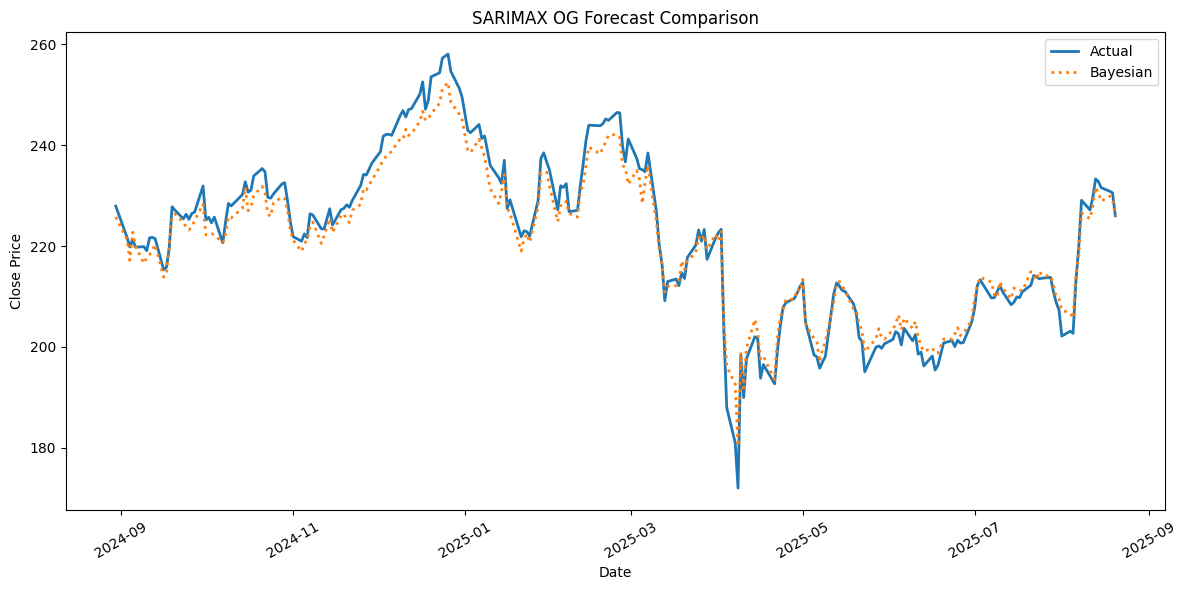

In [5]:
if __name__ == '__main__':
    cfg = SARIMAXConfig(
        data_path='datasets/AAPL_xlstm_date.csv',
        test_size=0.2,
        S=5  # business‐week seasonality
    )
    main(cfg)